<a href="https://colab.research.google.com/github/rahiakela/computer-vision-research-and-practice/blob/main/vision-language-models/01_text_to_image_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Building a Text-to-Image Retrieval Application

In this exercise, we will build a multimodal application that retrieves images from a text query.

The approach has two steps:
1. **Offline indexing**: Index all images using the image tower of SigLIP, get the embeddings and store them.
2. **Online inference**: Get the embedding of the text query through the text tower, then find the closest image embeddings and retrieve those images.

We will use [FAISS](https://faiss.ai/index.html) to store and search the embeddings. If you are on a GPU, make sure to check the CUDA version with the command `nvidia-smi`, and install the appropriate faiss-gpu version. For CUDA 12.x it is faiss-gpu-cu12.

You also need the sentencepiece library, so let's make sure you have everything we need.

In [ ]:
!pip install -Uq transformers==5.3.0
!pip install -q datasets faiss-gpu-cu12 sentencepiece

## Load the Model

We will use [siglip-base-patch16-224](https://huggingface.co/google/siglip-base-patch16-224), this is the SigLIP with patch size 16 and resolution 224, 224.

In [ ]:
import torch
from transformers import AutoProcessor, AutoModel, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
model_id = "google/siglip-base-patch16-224"
model = AutoModel.from_pretrained(model_id, device_map="auto").eval()
processor = AutoProcessor.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)

## Authentication

This is a toy example, so we will be using a small portion of the dataset. We will stream 100 examples from the dataset. To do so, you need to authenticate yourself first. You can use either `login` from the `huggingface_hub` library, or in the command line interface, use `huggingface-cli login`.

In [ ]:
from huggingface_hub import login
login()

The tokens are stored under the environmental variable `HF_TOKEN`.

In [ ]:
import os
API_TOKEN = os.environ.get('HF_TOKEN')

## Stream the Dataset

Let's stream 100 examples from the dataset.

In [ ]:
import requests

headers = {"Authorization": f"Bearer {API_TOKEN}"}
API_URL = "https://datasets-server.huggingface.co/rows?dataset=vlmbook/wikiart&config=default&split=train&offset=1&length=100"

def query():
    response = requests.get(API_URL, headers=headers)
    return response.json()

data = query()
data["rows"][0]

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## Visualize an Example

Let's see how the image looks like. The images are large, you need to downscale them to see properly in the notebook.

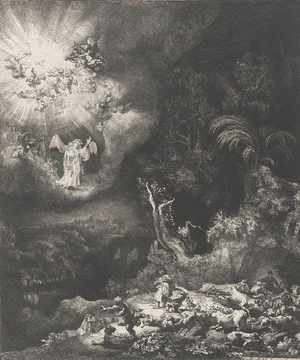

In [ ]:
from PIL import Image

url = data["rows"][0]["row"]["image"]["src"]
image = Image.open(requests.get(url, stream=True).raw)
width = 300
ratio = (width / float(image.size[0]))
height = int((float(image.size[1]) * float(ratio)))
img = image.resize((width, height), Image.Resampling.LANCZOS)
display(img)

## Index the Dataset

Now let's get to indexing the dataset. Below are helper functions to index the dataset. `add_vector` adds a vector to FAISS and `embed_siglip` processes the image and gets image embeddings from the SigLIP model, so we will first call `embed_siglip` and store the embedding output with `add_vector`.

In [ ]:
import numpy as np
import faiss

def add_vector(embedding, index):
    vector = embedding.detach().cpu().numpy()
    vector = np.float32(vector)
    faiss.normalize_L2(vector)
    index.add(vector)

def embed_siglip(image):
    with torch.no_grad():
        inputs = processor(images=image, return_tensors="pt").to(device)
        image_features = model.get_image_features(**inputs)
        return image_features.pooler_output

Now, let's initialize the FAISS index, and start indexing the dataset. SigLIP model outputs 1152-dimensional vectors, and you need to pass it to `IndexFlatL2` to create your index.

In [ ]:
index = faiss.IndexFlatL2(768)

for elem in data["rows"]:
    url = elem["row"]["image"]["src"]
    image = Image.open(requests.get(url, stream=True).raw)
    clip_features = embed_siglip(image)
    add_vector(clip_features, index)

You can save this index so you can do the search with it later on. To save, you can call `write_index` and to load, you can use `read_index`.

In [ ]:
faiss.write_index(index, "./siglip_70k.index")
index = faiss.read_index("./siglip_70k.index")

## Search with a Text Query

You can now search with the text query. Let's get the artworks with a woman in them. To do this, you need to process the text input and get the text embeddings, then you need to pass the text through the tokenizer, which can be accessed with `processor.tokenizer`.

In [ ]:
prompt = "a woman"
text_token = processor.tokenizer([prompt], return_tensors="pt").to(device)
text_features = model.get_text_features(**text_token)
text_features = text_features.pooler_output.detach().cpu().numpy()
text_features = np.float32(text_features)
faiss.normalize_L2(text_features)

We will get the two most matching artworks. `index.search` returns the distance between your query and closest images, along with the indices of them, which can be mapped to the dataset to get the actual images.

In [ ]:
distances, indices = index.search(text_features, 2)
print(indices)

[[50 18]]


## Display Retrieved Images

Let's see the retrieved images.

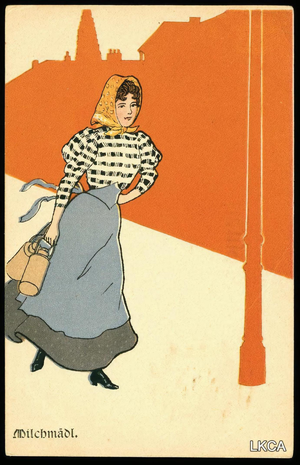

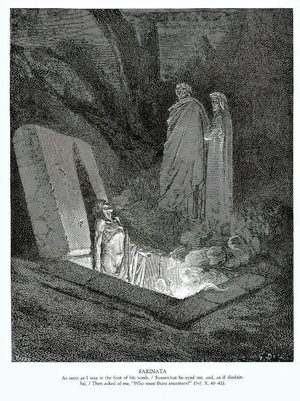

In [ ]:
for elem in indices[0]:
    url = data["rows"][elem]["row"]["image"]["src"]
    image = Image.open(requests.get(url, stream=True).raw)

    # downscale
    width = 300
    ratio = (width / float(image.size[0]))
    height = int((float(image.size[1]) * float(ratio)))
    img = image.resize((width, height), Image.Resampling.LANCZOS)
    display(img)

And voila! You have built your first multimodal application.